In [1]:
###########  FLOWSql API client Python code  block to copy and paste ###########
import requests

class FLOWSql:
    def __init__(self, api_key: str,
                    url: str = "https://flows.phys.au.dk/api/sqlquery.php",
                    timeout: int = 30):
        """
        Initialize FLOWSql API client.

        Parameters
        ----------
        api_key : str
            API token for FLOWSql.
        url : str
            FLOWSql endpoint URL.
        timeout : int
            Request timeout in seconds.
        """
        self.api_key = api_key
        self.url = url
        self.timeout = timeout

        self.session = requests.Session()
        self.session.headers.update({
            "Authorization": f"Bearer {self.api_key}"
        })

    def query(self, sql: str, admin: bool = False) -> dict:
        """
        Execute an SQL query.

        Returns
        -------
        dict
            Select queries JSON format:
                {
                    "type": "select",
                    "columns": [...],
                    "rows": [...],
                    "count": int
                }

            Write queries (DELETE, UPDATE etc.) JSON format:
                {
                    "type": "write",
                    "affected_rows": int
                }
        """

        try:
            response = self.session.post(
                self.url,
                data={"query": sql, "admin": admin},
                timeout=self.timeout
            )
            response.raise_for_status()
        except requests.RequestException as e:
            raise FLOWSqlError(f"HTTP error: {e}") from e

        try:
            data = response.json()
        except ValueError:
            raise FLOWSqlError(f"Invalid JSON response: {response.text}")

        if not data.get("success"):
            raise FLOWSqlError(data.get("error", "Unknown API error"))

        if data["type"] == "select":
            return {
                "type": "select",
                "columns": data.get("columns", []),
                "rows": data.get("rows", []),
                "count": data.get("count", 0)
            }

        if data["type"] == "write":
            return {
                "type": "write",
                "affected_rows": data.get("affected_rows", 0)
            }

        raise FLOWSqlError(f"Unknown response format: {data}")


    def close(self):
        """Close HTTP session."""
        self.session.close()

class FLOWSqlError(Exception):
    """Raised when the SQL API returns an error."""
    pass

################# END FLOWSql API client Python code block  ###########


#### Set the FLOWS_API_KEY variable appropriately,
#### this hack may not work unless FLOWS_API_KEY is set in the bash environment ####
FLOWS_API_KEY=!bash -i -c 'echo $FLOWS_API_KEY'
FLOWS_API_KEY=FLOWS_API_KEY[-1]

In [2]:
fsql = FLOWSql(FLOWS_API_KEY)
result = fsql.query('''SELECT f.path, f.photfilter, t.target_name, s.sitename
FROM files f
JOIN targets t ON f.targetid = t.targetid
JOIN sites s ON f.site = s.siteid
WHERE f.datatype = 2
AND s.sitename = 'NOT'
AND t.target_status = 'target' ''')

filelist = [tuple(x.values()) for x in result['rows']]

#AND t.project = 'flows'

In [3]:
from itertools import groupby
import re

def get_highest_version_files(filelist):
    # Extract base name (without version) for grouping
    def base_key(entry):
        path = entry[0]
        # Remove version suffix to get base name
        base = re.sub(r'v\d+/photometry-.+', '', path)
        # Also normalize using filter and object name
        return (base, entry[1], entry[2])
    
    def version_num(entry):
        match = re.search(r'v(\d+)\.ecsv$', entry[0])
        return int(match.group(1)) if match else 0
    
    # Group by base path, keep only max version
    from collections import defaultdict
    groups = defaultdict(list)
    for entry in filelist:
        groups[base_key(entry)].append(entry)
    
    return [max(group, key=version_num) for group in groups.values()]

highest = get_highest_version_files(filelist)
len(highest)

1078

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from collections import defaultdict
import re
from astropy.stats import SigmaClip, mad_std
import copy

# --- Config ---
basedir='/nerdrage/calc/archive/photometry/'

color_bases = {
    'H_mag': ['J_mag', 'H_mag'],
    'J_mag': ['J_mag', 'H_mag'],
    'K_mag': ['H_mag', 'K_mag'],  # try with J - H
    'Y_mag': ['H_mag', 'K_mag'],  # Y need redefined
    'B_mag': ['B_mag', 'V_mag'],
    'V_mag': ['B_mag', 'V_mag'],
    'u_mag': ['u_mag', 'g_mag'],
    'g_mag': ['g_mag', 'r_mag'],
    'r_mag': ['g_mag', 'r_mag'],
    'i_mag': ['r_mag', 'i_mag'],
    'z_mag': ['i_mag', 'z_mag'],
}



filter_groups = defaultdict(list)
for filepath, filt, objname, sitename in highest:
    filt=filt[0:1]
    filter_groups[filt].append((filepath, objname))
filter_groups.keys()

dict_keys(['g', 'i', 'r', 'u', 'B', 'V', 'J', 'H', 'K', 'z', 'R'])

In [5]:
%%script false --no-raise-error   # skip this cell
for filt in list(filter_groups.keys()):
    file_entries=filter_groups[filt] 
    print("No of files to read for filter",filt,len(file_entries))
    mag_col = f'{filt}_mag'

    if mag_col not in color_bases:
        print(f"Skipping filter {filt}: no color_bases entry for {mag_col}")
        continue

    color_col0, color_col1 = color_bases[mag_col]  # e.g. ['J_mag', 'H_mag']

    all_color, all_Dmag, all_Dmag_err = [], [], []

    for filepath, objname in file_entries:
        try:
            t = Table.read(basedir + filepath, format='ascii.ecsv')
            t = t[t['starid']>0]  # skip SN mag

            # Required columns
            needed = ['flux_psf', 'flux_psf_error', 'mag', 'mag_error',
                      mag_col, color_col0, color_col1]
            if not all(col in t.colnames for col in needed):
                missing = [c for c in needed if c not in t.colnames]
                print(f"  Skipping {filepath}: missing columns {missing}")
                continue

            flux     = np.array(t['flux_psf'].data,        dtype=float)
            flux_err = np.array(t['flux_psf_error'].data,  dtype=float)
            mag      = np.array(t['mag'].data,             dtype=float)
            ref_mag  = np.array(t[mag_col].data,           dtype=float)
            col0     = np.array(t[color_col0].data,        dtype=float)
            col1     = np.array(t[color_col1].data,        dtype=float)

            # Mask out bad values
            valid = (flux > 0) & np.isfinite(flux) & np.isfinite(ref_mag) \
                  & np.isfinite(col0) & np.isfinite(col1) & (ref_mag !=0) & (col0 !=0) & (col1 !=0) & (col0 != col1)
            flux     = flux[valid];     flux_err = flux_err[valid]
            mag      = mag[valid];      ref_mag  = ref_mag[valid]
            col0     = col0[valid];     col1     = col1[valid]

            # Instrumental magnitude and error
            instmag       = -2.5 * np.log10(flux) + 24
            instmag_error = 2.5 * flux_err / flux / np.log(10)

            # Axes
            y = mag - ref_mag                  # instrumental - catalog mag
            x = col0 - col1                        # e.g. J_mag - H_mag

            if np.any(x==0):
                print(f"  x==0 for {basedir+filepath}")
                

            all_color.append(x)
            all_Dmag.append(y)
            all_Dmag_err.append(instmag_error)   # This is to ensure we use the photometry error only

        except Exception as e:
            print(f"  Error reading {filepath}: {e}")
            continue

    if not all_x:
        print(f"No valid data for filter {filt}, skipping plot.")
        continue

    color_term=[[0, 0]]

    while True:
        #print(f"Niter {len(color_term)}, -> Color term: {color_term[-1]}")
        CP_all_color=copy.deepcopy(all_color)
        CP_all_Dmag=copy.deepcopy(all_Dmag)
        CP_all_Dmag_err=copy.deepcopy(all_Dmag_err)

        ### Here we calculate ZP with CT correction applied for each data set in the list
        for i in range(len(CP_all_color)):
            CP_all_Dmag[i] = CP_all_Dmag[i] - color_term[-1][0] * CP_all_color[i]
            sigclip = SigmaClip(sigma=3, maxiters=5)
            mask = ~sigclip(CP_all_Dmag[i]).mask
            all_Dmag[i] = all_Dmag[i] - np.median(CP_all_Dmag[i][mask])
            all_Dmag_err[i] = np.sqrt( all_Dmag_err[i]**2 + mad_std(CP_all_Dmag[i][mask])**2 )


        # Concatenate across all files for this filter
        X    = np.concatenate(all_color)
        Y    = np.concatenate(all_Dmag)
        Yerr = np.concatenate(all_Dmag_err)

        # --- Linear fit (weighted by 1/err^2) ---
        # Mask out any non-finite values or zero/negative errors
        fit_mask = (np.isfinite(X) & np.isfinite(Y) & np.isfinite(Yerr) & (Yerr > 0) & (Yerr <1))


        if fit_mask.sum() < 2:
            print(f"  Not enough valid points to fit for filter {filt}")
            continue
        if len(Xf) < 3:
            print(f"  Not enough points for covariance estimate")
            continue

        Xf, Yf, Yef = X[fit_mask], Y[fit_mask], Yerr[fit_mask]


        from astropy.stats import SigmaClip
        sigclip = SigmaClip(sigma=3, maxiters=5)
        fit_mask2 = ~sigclip(Xf).mask & ~sigclip(Yf).mask
        Xf, Yf, Yef = Xf[fit_mask2], Yf[fit_mask2], Yef[fit_mask2]
        print(f"Sigma clipped along X and Y, discarded {(~fit_mask2).sum()} points")

        weights = 1.0 / Yef**2
        coeffs, cov = np.polyfit(Xf, Yf, deg=1, w=weights, cov=True)
        slope, intercept = coeffs
        slope_error, intercept_error = np.sqrt(np.diag(cov))
        fit_line = np.poly1d(coeffs)

        if np.abs(color_term[-1][0] -slope) < np.abs(slope)/10000:  # This is 4 decimal point accurate?
            color_term.append([slope,slope_error])
            break
        color_term.append([slope,slope_error])
        
    #print("Final color term: ", color_term)


    x_fit = np.linspace(Xf.min(), Xf.max(), 300)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(np.arange(1,len(color_term)), np.array(color_term)[1:,0], yerr=np.array(color_term)[1:,1], fmt='o-', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars')

    ax.set_xlabel('Iteration', fontsize=13)
    ax.set_ylabel('Color term', fontsize=13)
    ax.set_title(f'({color_col0} $-$ {color_col1}) color term convergence in {len(color_term)} iterations', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(Xf, Yf, yerr=Yef, fmt='o', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars')
    ax.plot(x_fit, fit_line(x_fit), 'r-', lw=2,
            label=f'Fit: CT={slope:.4f}±{slope_error:.4f}, x0={intercept:.4f}±{intercept_error:.4f}')

    ax.set_xlabel(f'({color_col0} $-$ {color_col1})_cat,std', fontsize=13)
    ax.set_ylabel(f'{mag_col},nat $-$ {mag_col}_cat,std', fontsize=13)
    ax.set_title(f'Filter {filt}  |  Color delta_magnitude fit |  N={len(Xf)}', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()

    print(f"\nFilter {filt}:")
    print(f"  x-axis : {color_col0} - {color_col1}")
    print(f"  y-axis : instmag - {mag_col}")
    print(f"  color_term = {slope:.6f} ± {slope_error:.6f}")
    print(f"  intercept  = {intercept:.6f} ± {intercept_error:.6f}")
    print(f"  N stars    = {len(Xf)}")


In [6]:
def color_fitter(X, Y, Xerr=None, Yerr=None, fitter='lin'):
    if fitter == 'linmix':
        from linmix.linmix import LinMix
        lm=LinMix(X, Y, Xerr, Yerr, parallelize=True, nchains=10)
        lm.run_mcmc(miniter=500, maxiter=5000, silent=True)

        slope, intercept = (np.median(lm.chain['beta']), np.median(lm.chain['alpha']))
        slope_error, intercept_error = (np.std(lm.chain['beta']), np.std(lm.chain['alpha']))
        return ([intercept,intercept_error], [slope,slope_error], np.poly1d([slope,intercept]), lm.chain)

    elif fitter == 'lin':
        if Xerr is not None:
            weights = 1.0 / (Yerr**2 + Xerr**2)
        else:
            weights = 1.0 / Yerr**2
        coeffs, cov = np.polyfit(X, Y, deg=1, w=weights, cov=True)
        slope, intercept = coeffs
        slope_error, intercept_error = np.sqrt(np.diag(cov))
        return ([intercept,intercept_error], [slope,slope_error], np.poly1d(coeffs), None)
    else:
        raise ValueError(f"Unknown fitter type: {fitter}")
  
        

No of files to read for filter g 93


Niter 12, -> Color term: [np.float64(0.10444414499262414), np.float64(0.0023157113427138797)]                                      
Filter g:
  x-axis : g_mag - r_mag
  y-axis : instmag - g_mag
  color_term = 0.104446 ± 0.002257
  intercept  = 0.000224 ± 0.001730
  N stars    = 1667
  N clipped  = 149


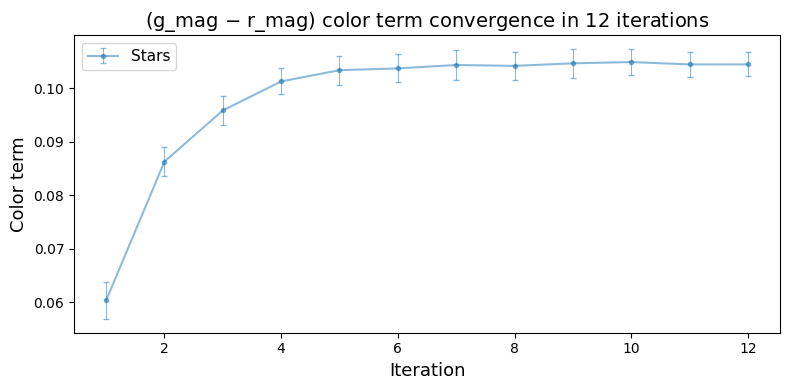

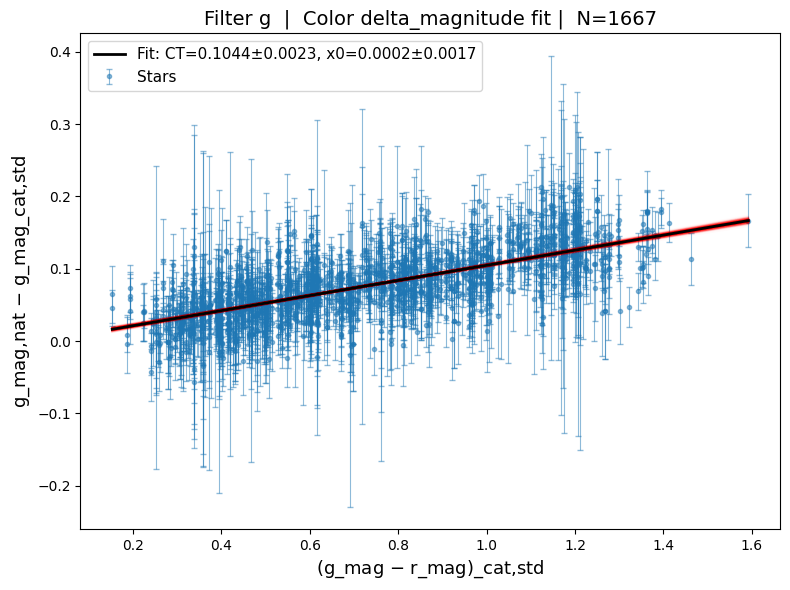

No of files to read for filter i 114
Niter 4, -> Color term: [np.float64(-0.07003931472231381), np.float64(0.0024148191729687395)]                                      
Filter i:
  x-axis : r_mag - i_mag
  y-axis : instmag - i_mag
  color_term = -0.070005 ± 0.002263
  intercept  = 0.002351 ± 0.001136
  N stars    = 2920
  N clipped  = 423


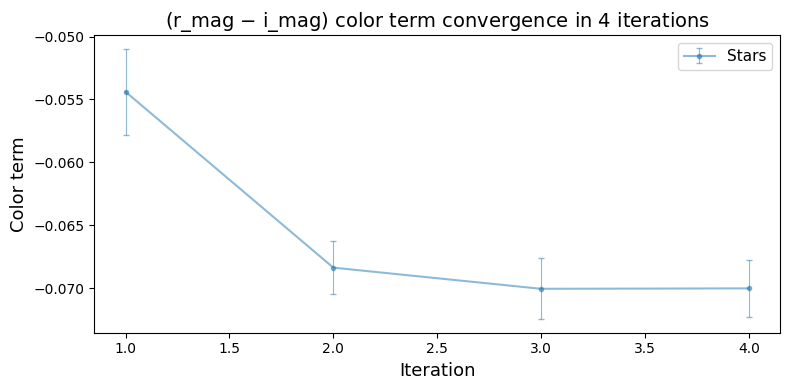

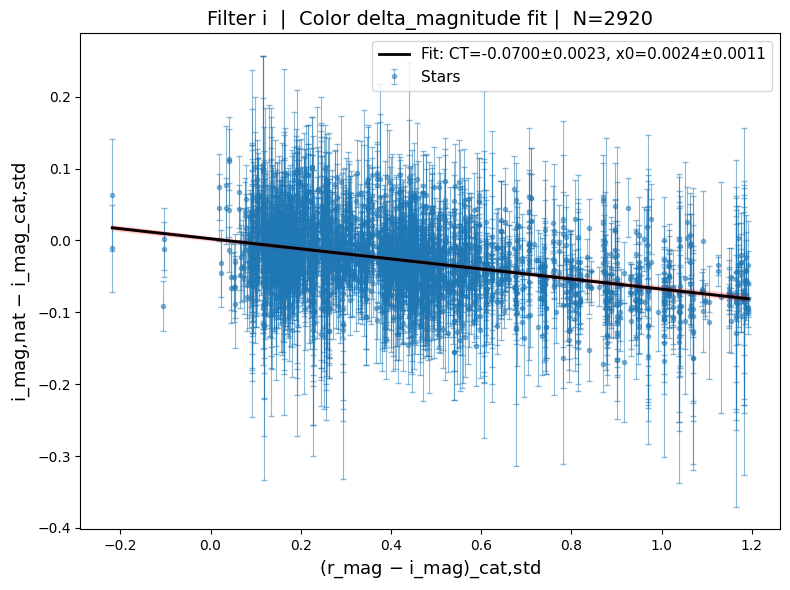

No of files to read for filter r 111
Niter 31, -> Color term: [np.float64(0.0014699469427029146), np.float64(0.0018110809402640442)]                                      
Niter 32, -> Color term: [np.float64(0.001734695652160854), np.float64(0.0018942108202812617)]
Niter 33, -> Color term: [np.float64(0.0017258896978926473), np.float64(0.0018845912529014367)]
Niter 34, -> Color term: [np.float64(0.0016309710004386159), np.float64(0.0018525797047712707)]
Niter 35, -> Color term: [np.float64(0.001477593962012098), np.float64(0.0018038573948173024)]
Niter 36, -> Color term: [np.float64(0.0015610322118440323), np.float64(0.0017988172313007133)]
Niter 37, -> Color term: [np.float64(0.0015131975142512978), np.float64(0.001786185735618755)]
Niter 38, -> Color term: [np.float64(0.0015713230226874885), np.float64(0.0019097990077546424)]
Niter 39, -> Color term: [np.float64(0.0015461334107602553), np.float64(0.0018979715448796974)]
Niter 40, -> Color term: [np.float64(0.001652476481457079), np.f

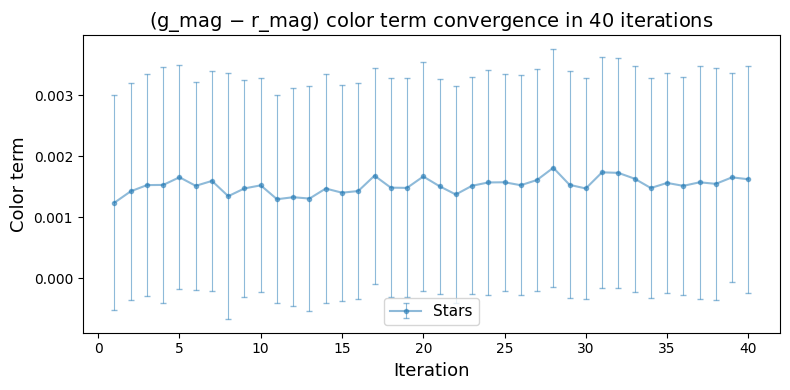

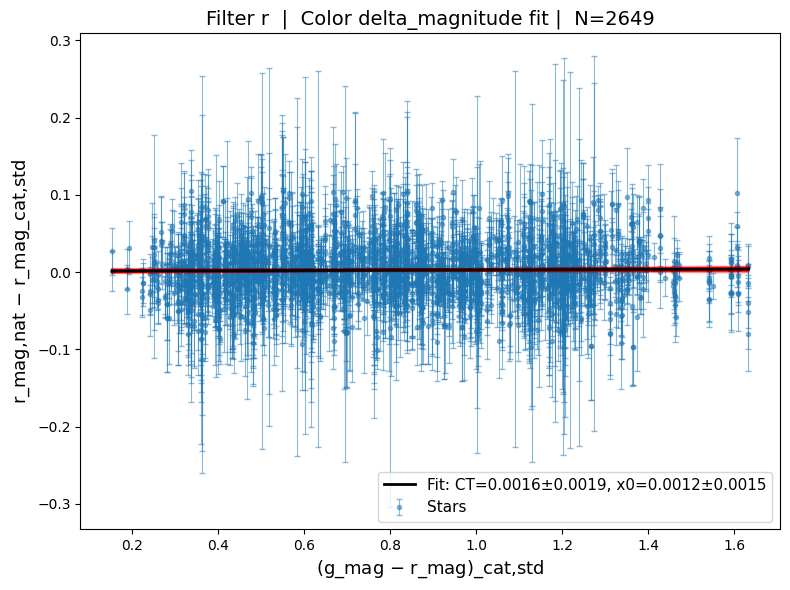

No of files to read for filter u 23


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Filter u:
  x-axis : u_mag - g_mag
  y-axis : instmag - u_mag
  color_term = -0.050788 ± 0.009594
  intercept  = 0.002412 ± 0.015277
  N stars    = 109
  N clipped  = 8


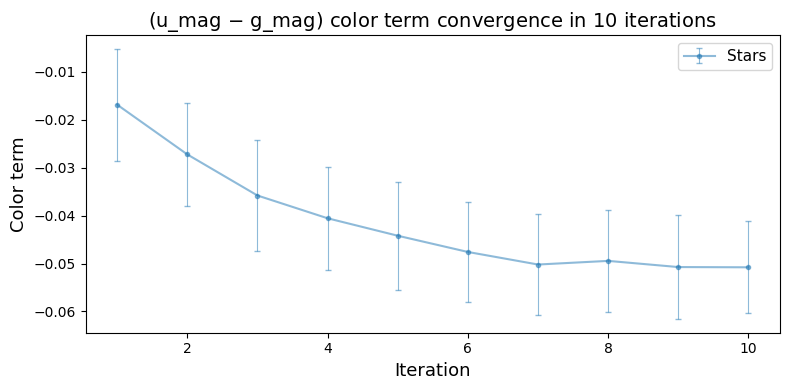

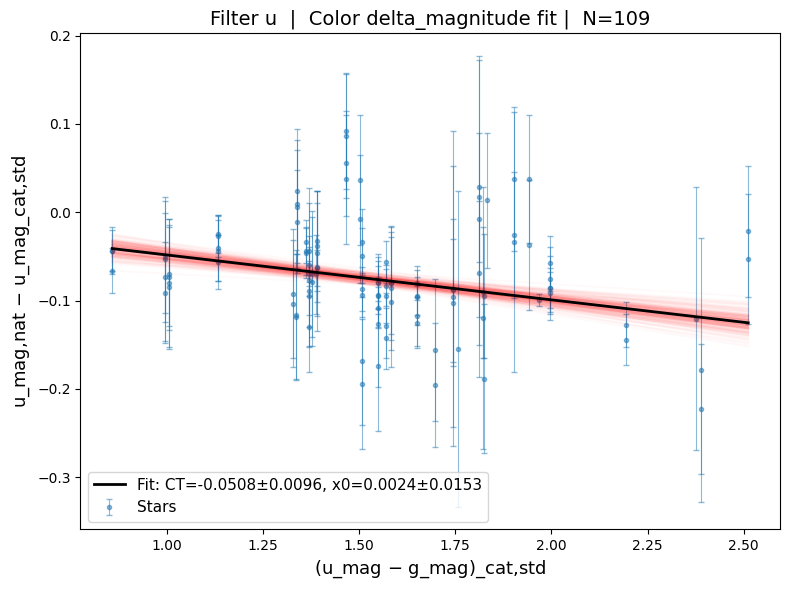

No of files to read for filter B 109
Niter 31, -> Color term: [np.float64(-0.05145899260126251), np.float64(0.008476433453770256)]                                       
Niter 32, -> Color term: [np.float64(-0.050655854610845805), np.float64(0.007258145403268113)]
Niter 33, -> Color term: [np.float64(-0.05122568615104269), np.float64(0.007860635929724835)]
Niter 34, -> Color term: [np.float64(-0.050393121828602186), np.float64(0.007586761818002404)]
Niter 35, -> Color term: [np.float64(-0.049537911458582724), np.float64(0.006812542618030884)]
Niter 36, -> Color term: [np.float64(-0.04886359580586065), np.float64(0.008360606745932973)]
Niter 37, -> Color term: [np.float64(-0.05094716633705014), np.float64(0.009277231364718405)]
Niter 38, -> Color term: [np.float64(-0.049852229172273235), np.float64(0.008734719616836929)]
Niter 39, -> Color term: [np.float64(-0.047645946992495865), np.float64(0.008219906843271863)]
Niter 40, -> Color term: [np.float64(-0.05172853756785763), np.float64(0.

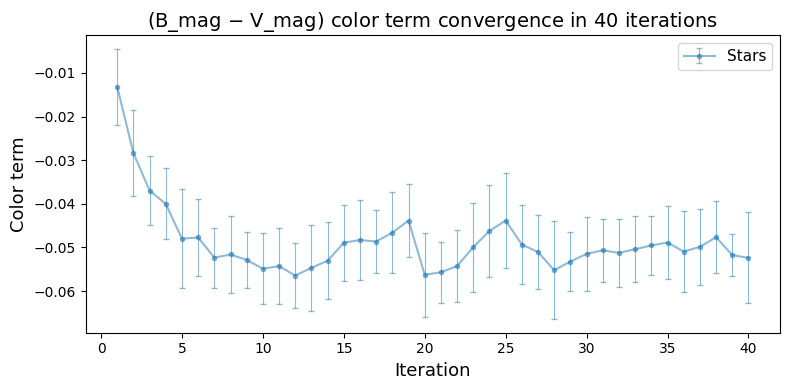

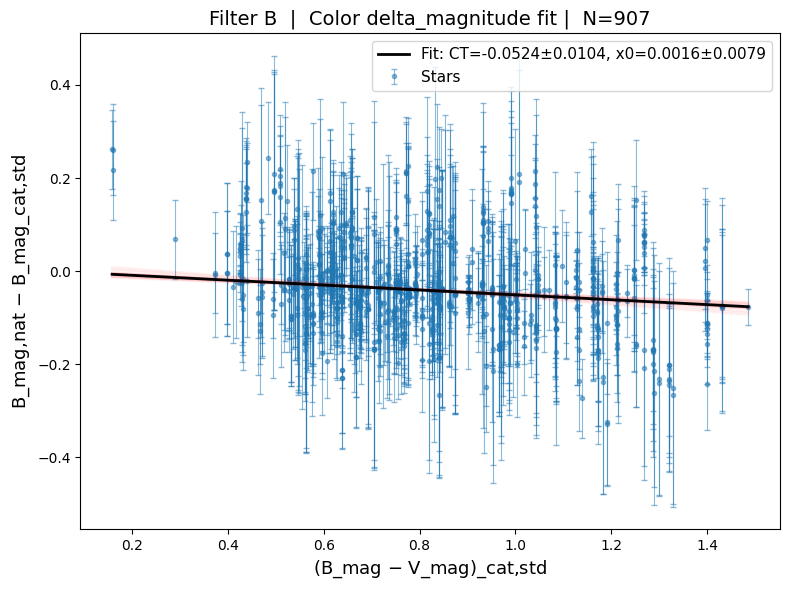

No of files to read for filter V 102
Niter 20, -> Color term: [np.float64(0.06337380904573248), np.float64(0.00744688170829946)]                                       
Filter V:
  x-axis : B_mag - V_mag
  y-axis : instmag - V_mag
  color_term = 0.063347 ± 0.006380
  intercept  = 0.002588 ± 0.005014
  N stars    = 782
  N clipped  = 182


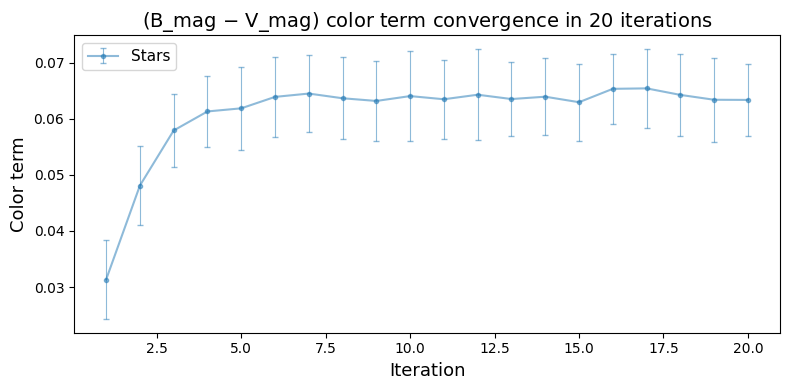

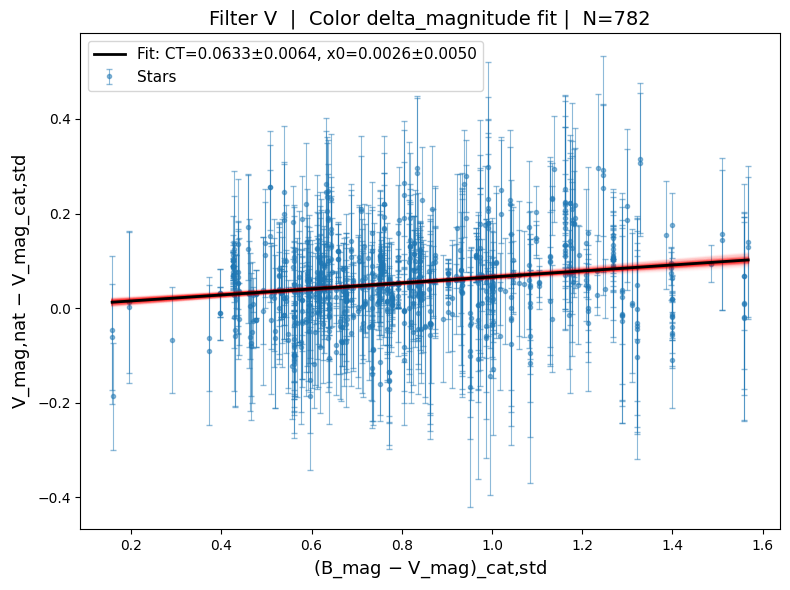

No of files to read for filter J 236


In [14]:
for filt in list(filter_groups.keys()):
    file_entries=filter_groups[filt] 
    print("No of files to read for filter",filt,len(file_entries))
    mag_col = f'{filt}_mag'

    if mag_col not in color_bases:
        print(f"Skipping filter {filt}: no color_bases entry for {mag_col}")
        continue

    color_col0, color_col1 = color_bases[mag_col]  # e.g. ['J_mag', 'H_mag']

    all_color, all_Dmag, all_Dmag_err = [], [], []

    for filepath, objname in file_entries:
        try:
            t = Table.read(basedir + filepath, format='ascii.ecsv')
            t = t[t['starid']>0]  # skip SN mag

            # Required columns
            needed = ['flux_psf', 'flux_psf_error', 'mag', 'mag_error',
                      mag_col, color_col0, color_col1]
            if not all(col in t.colnames for col in needed):
                missing = [c for c in needed if c not in t.colnames]
                print(f"  Skipping {filepath}: missing columns {missing}")
                continue

            flux     = np.array(t['flux_psf'].data,        dtype=float)
            flux_err = np.array(t['flux_psf_error'].data,  dtype=float)
            mag      = np.array(t['mag'].data,             dtype=float)
            ref_mag  = np.array(t[mag_col].data,           dtype=float)
            col0     = np.array(t[color_col0].data,        dtype=float)
            col1     = np.array(t[color_col1].data,        dtype=float)

            # Mask out bad values
            valid = (flux > 0) & np.isfinite(flux) & np.isfinite(ref_mag) \
                  & np.isfinite(col0) & np.isfinite(col1) & (ref_mag !=0) & (col0 !=0) & (col1 !=0) & (col0 != col1)
            flux     = flux[valid];     flux_err = flux_err[valid]
            mag      = mag[valid];      ref_mag  = ref_mag[valid]
            col0     = col0[valid];     col1     = col1[valid]

            # Instrumental magnitude and error
            instmag       = -2.5 * np.log10(flux) + 24
            instmag_error = 2.5 * flux_err / flux / np.log(10)

            # Axes
            y = mag - ref_mag                  # instrumental - catalog mag
            x = col0 - col1                        # e.g. J_mag - H_mag

            if np.any(x==0):
                print(f"  x==0 for {basedir+filepath}")
                

            all_color.append(x)
            all_Dmag.append(y)
            all_Dmag_err.append(instmag_error)   # This is to ensure we use the photometry error only

        except Exception as e:
            print(f"  Error reading {filepath}: {e}")
            continue

    if not all_Dmag:
        print(f"No valid data for filter {filt}, skipping plot.")
        continue

    color_term=[[0, 0]]

    nlBuf=''
    while True:
        if len(color_term) > 30:
            print(f"Niter {len(color_term)}, -> Color term: {color_term[-1]}")
            if len(color_term) > 40:
                print("Warning!! Didn't converge")
                break
        else:
            print(f"Niter {len(color_term)}, -> Color term: {color_term[-1]}                                      ",end='\r')
        CP_all_color=copy.deepcopy(all_color)
        CP_all_Dmag=copy.deepcopy(all_Dmag)
        CP_all_Dmag_err=copy.deepcopy(all_Dmag_err)

        ### Here we calculate ZP with CT correction applied for each data set in the list
        for i in range(len(CP_all_color)):
            tmp = CP_all_Dmag[i] - color_term[-1][0] * CP_all_color[i]
            sigclip = SigmaClip(sigma=3, maxiters=5)
            mask = ~sigclip(tmp).mask
            CP_all_Dmag[i] = CP_all_Dmag[i] - np.median(tmp[mask])
            CP_all_Dmag_err[i] = np.sqrt( CP_all_Dmag_err[i]**2 + (np.std(tmp[mask]))**2 )      # sigma= MAD*1.4826 
            #CP_all_color[i] = CP_all_color[i][mask]


        # Concatenate across all files for this filter
        X    = np.concatenate(CP_all_color)
        Y    = np.concatenate(CP_all_Dmag)
        Yerr = np.concatenate(CP_all_Dmag_err)

        # --- Linear fit (weighted by 1/err^2) ---
        # Mask out any non-finite values or zero/negative errors
        fit_mask = (np.isfinite(X) & np.isfinite(Y) & np.isfinite(Yerr) & (Yerr > 0) & (Yerr <.3))


        if fit_mask.sum() < 2:
            print(f"  Not enough valid points to fit for filter {filt}  ")
            break

        Xf, Yf, Yef = X[fit_mask], Y[fit_mask], Yerr[fit_mask]
        
        if len(Xf) < 3:
            print(f"  Not enough points for covariance estimate   ")
            break


        from astropy.stats import SigmaClip
        fit_mask = ~SigmaClip(sigma=3, maxiters=5)(Xf).mask & ~SigmaClip(sigma=3, maxiters=5)(Yf).mask
        #Xf, Yf, Yef = Xf[fit_mask], Yf[fit_mask], Yef[fit_mask]
        #print(f"Sigma clipped along X, discarded {(~fit_mask).sum()} points")

        
        sigclip = SigmaClip(sigma=3, maxiters=3)
        chain = None
        for i in range(5):
            #weights = 1.0 / Yef[fit_mask]**2
            #coeffs, cov = np.polyfit(Xf[fit_mask], Yf[fit_mask], deg=1, w=weights, cov=True)
            #slope, intercept = coeffs
            #slope_error, intercept_error = np.sqrt(np.diag(cov))
            #fit_line = np.poly1d(coeffs)
            (intercept, intercept_error), (slope, slope_error), fit_line, chain = color_fitter(Xf[fit_mask], Yf[fit_mask], Xerr=None, Yerr=Yef[fit_mask], fitter='linmix')
            
            tmp=Yf[fit_mask]-fit_line(Xf[fit_mask])
            fit_mask[fit_mask] = fit_mask[fit_mask] & ~sigclip(tmp).mask
        Xf, Yf, Yef = Xf[fit_mask], Yf[fit_mask], Yef[fit_mask]

        if np.abs(color_term[-1][0] -slope) < np.abs(slope)/1000:  # This is 4 dec sig. fig. point accurate?
        #if np.abs(color_term[-1][0] -slope) < 0.0005:  # This is 3 decimal point accurate?
            color_term.append([slope,slope_error])
            break
        color_term.append([slope,slope_error])
        
    #print("Final color term: ", color_term)

    print(f"\nFilter {filt}:")
    print(f"  x-axis : {color_col0} - {color_col1}")
    print(f"  y-axis : instmag - {mag_col}")
    print(f"  color_term = {slope:.6f} ± {slope_error:.6f}")
    print(f"  intercept  = {intercept:.6f} ± {intercept_error:.6f}")
    print(f"  N stars    = {len(Xf)}")
    print(f"  N clipped  = {len(np.concatenate(all_color)) - len(Xf)}")



    #chain=None
    #(intercept, intercept_error), (slope, slope_error), fit_line, chain = color_fitter(Xf, Yf, Xerr=None, Yerr=Yef, fitter='linmix')
    #color_term.append([slope,slope_error])
    #
    #print(f"\nLinMax Result:")
    #print(f"\nFilter {filt}:")
    #print(f"  x-axis : {color_col0} - {color_col1}")
    #print(f"  y-axis : instmag - {mag_col}")
    #print(f"  color_term = {slope:.6f} ± {slope_error:.6f}")
    #print(f"  intercept  = {intercept:.6f} ± {intercept_error:.6f}")
    #print(f"  N stars    = {len(Xf)}")
    #print(f"  N clipped  = {len(np.concatenate(all_color)) - len(Xf)}")



    x_fit = np.linspace(Xf.min(), Xf.max(), 300)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(np.arange(1,len(color_term)), np.array(color_term)[1:,0], yerr=np.array(color_term)[1:,1], fmt='o-', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars')

    ax.set_xlabel('Iteration', fontsize=13)
    ax.set_ylabel('Color term', fontsize=13)
    ax.set_title(f'({color_col0} $-$ {color_col1}) color term convergence in {len(color_term)-1} iterations', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(Xf, Yf, yerr=Yef, fmt='o', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars', zorder=1)
    ax.plot(x_fit, fit_line(x_fit), 'k-', lw=2,
            label=f'Fit: CT={slope:.4f}±{slope_error:.4f}, x0={intercept:.4f}±{intercept_error:.4f}', zorder=3)

    if chain is not None:
        for i in range(0, len(chain), 50):
            ys = chain[i]['alpha'] + x_fit * chain[i]['beta']
            ax.plot(x_fit, ys, color='r', alpha=0.02, zorder=2)

    ax.set_xlabel(f'({color_col0} $-$ {color_col1})_cat,std', fontsize=13)
    ax.set_ylabel(f'{mag_col},nat $-$ {mag_col}_cat,std', fontsize=13)
    ax.set_title(f'Filter {filt}  |  Color delta_magnitude fit |  N={len(Xf)}', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()


In [90]:
np.arange(1,5)

array([1, 2, 3, 4])

In [42]:
(~fit_mask2).sum()

np.int64(-4380)

In [24]:
fit_mask

array([ True,  True,  True, ...,  True,  True,  True], shape=(4777,))

In [11]:
from astropy.stats import SigmaClip
from numpy.random import normal
from numpy import arange, diag, ones
data = arange(5) + normal(0., 0.05, (5, 5)) + diag(ones(5))

In [12]:
data

array([[ 9.71773803e-01,  1.01197401e+00,  1.94576824e+00,
         2.94290633e+00,  3.99295774e+00],
       [ 2.59221507e-02,  1.93513775e+00,  2.11468437e+00,
         2.95972669e+00,  4.00913133e+00],
       [-4.71071179e-02,  9.72828282e-01,  2.94113710e+00,
         3.02105949e+00,  4.08151615e+00],
       [ 3.85488300e-03,  9.45252117e-01,  2.01866065e+00,
         4.01135240e+00,  4.02180629e+00],
       [-1.67160189e-02,  1.05346809e+00,  1.99961817e+00,
         3.04117173e+00,  5.01666153e+00]])

In [17]:
sigclip = SigmaClip(sigma=2.3)
m=sigclip(data, axis=0).mask

In [20]:
m

array([[ True, False, False, False, False],
       [False,  True, False, False, False],
       [False, False,  True, False, False],
       [False, False, False,  True, False],
       [False, False, False, False,  True]])

In [1]:
!git clone https://github.com/jmeyers314/linmix.git

Cloning into 'linmix'...
remote: Enumerating objects: 446, done.
remote: Total 446 (delta 0), reused 0 (delta 0), pack-reused 446 (from 1)
Receiving objects: 100% (446/446), 544.64 KiB | 6.89 MiB/s, done.
Resolving deltas: 100% (250/250), done.


In [9]:
from linmix.linmix import LinMix

In [33]:
lm=LinMix(Xf, Yf, None, Yef, parallelize=True, nchains=10)
lm.run_mcmc(miniter=500, maxiter=5000, silent=False)


Iteration:  100
Rhat values for alpha, beta, log(sigma^2), mean(xi), log(var(xi)), atanh(corr(xi, eta)):
[1.35648605 1.36889388 1.89979531 1.00349339 1.00174746 1.95893433]

Iteration:  200
Rhat values for alpha, beta, log(sigma^2), mean(xi), log(var(xi)), atanh(corr(xi, eta)):
[1.38789558 1.41823095 1.77532977 1.00043514 0.99858551 1.79676803]

Iteration:  300
Rhat values for alpha, beta, log(sigma^2), mean(xi), log(var(xi)), atanh(corr(xi, eta)):
[1.24054956 1.26234152 1.70430139 1.00067795 0.99956819 1.79202259]

Iteration:  400
Rhat values for alpha, beta, log(sigma^2), mean(xi), log(var(xi)), atanh(corr(xi, eta)):
[1.16950767 1.18774055 1.68734766 1.0020933  0.99961642 1.76080669]

Iteration:  500
Rhat values for alpha, beta, log(sigma^2), mean(xi), log(var(xi)), atanh(corr(xi, eta)):
[1.12016982 1.11694243 1.59175181 1.00143731 0.99939317 1.66615695]

Iteration:  600
Rhat values for alpha, beta, log(sigma^2), mean(xi), log(var(xi)), atanh(corr(xi, eta)):
[1.11437495 1.10698082 1

In [23]:
LinMix?

Init signature:
LinMix(
    x,
    y,
    xsig=None,
    ysig=None,
    xycov=None,
    delta=None,
    K=3,
    nchains=4,
    parallelize=True,
    seed=None,
)
Docstring:     
A class to perform linear regression of `y` on `x` when there are measurement errors in
both variables.  The regression assumes:

eta = alpha + beta * xi + epsilon

x = xi + xerr

y = eta + yerr

Here, `alpha` and `beta` are the regression coefficients, `epsilon` is the intrinsic random
scatter about the regression, `xerr` is the measurement error in `x`, and `yerr` is the
measurement error in `y`.  `epsilon` is assumed to be normally-distributed with mean zero and
variance `sigsqr`.  `xerr` and `yerr` are assumed to be normally-distributed with means equal
to zero, variances `xsig`^2 and `ysig`^2, respectively, and covariance `xycov`. The
distribution of `xi` is modelled as a mixture of normals, with group proportions `pi`, means
`mu`, and variances `tausqr`.

Args:
    x(array_like): The observed independent

In [24]:
lm.chain

array([(-0.0019084 , 0.09758143, 1.75807278e-05, [0.31706043, 0.08379804, 0.59914154], [0.42589654, 1.18212561, 0.82852073], [0.01071783, 0.0022183 , 0.05370187], 0.88018138, 0.05107389, 0.01413886, 0.73049593, 0.29669096, 0.98967484),
       (-0.00173893, 0.09746508, 1.65404399e-05, [0.32967627, 0.09170075, 0.57862298], [0.4159232 , 1.18708467, 0.8263218 ], [0.01045205, 0.00201057, 0.05388878], 0.93842056, 0.08962326, 0.00639198, 0.72410535, 0.30302554, 0.9906516 ),
       (-0.00183003, 0.09727265, 1.87771153e-05, [0.33409086, 0.07712844, 0.58878071], [0.42077316, 1.19115211, 0.83979504], [0.01100999, 0.00198347, 0.04723391], 1.01431175, 0.06404722, 0.01569254, 0.72690328, 0.29509029, 0.98879631),
       ...,
       (-0.00261604, 0.0980335 , 1.24754261e-05, [0.10326744, 0.59445011, 0.30228245], [1.19067209, 0.78322211, 0.42065305], [0.00341416, 0.05242142, 0.0105092 ], 0.84685367, 0.04748189, 0.01707243, 0.71570016, 0.29497959, 0.99262323),
       (-0.00278951, 0.09840081, 1.30429598e

In [25]:
len(lm.chain)

30000

In [28]:
np.median(lm.chain['alpha']), np.median(lm.chain['beta'])

(np.float64(-0.00294525538744958), np.float64(0.09962464009557974))

In [34]:
coeffs

array([ 0.09565531, -0.0011706 ])

In [37]:
a,b,_ = (3,5,7)